In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
photom_columns = ['MORPHTYPE', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'FLUX_W1', 'FLUX_W2', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2', 'FIBERFLUX_Z', 'SHAPE_R', 'SERSIC', 'GAIA_PHOT_G_MEAN_MAG']
more_1_columns = ['DCHISQ', 'FRACFLUX_Z', 'FRACMASKED_Z', 'FRACIN_Z', 'SHAPE_E1', 'SHAPE_E2', 'FITBITS']
more_2_columns = ['PSFSIZE_Z']

cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/lrg/dr9_lrg_south_1.0.0_basic.fits'))
photom = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/lrg/dr9_lrg_south_1.0.0_photom.fits', columns=photom_columns))
more_1 = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/lrg/dr9_lrg_south_1.0.0_more_1.fits', columns=more_1_columns))
more_2 = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/lrg/dr9_lrg_south_1.0.0_more_2.fits', columns=more_2_columns))

cat = hstack([cat, photom, more_1, more_2], join_type='exact')
print(len(cat))

cat.rename_column('MORPHTYPE', 'TYPE')

9144035


In [4]:
maskbits = [1, 8, 9, 11, 12, 13]
mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean)/len(mask_clean))
cat = cat[mask_clean]
print(len(cat))

min_nobs = 2
mask = (cat['NOBS_G']>=min_nobs) & (cat['NOBS_R']>=min_nobs) & (cat['NOBS_Z']>=min_nobs)
cat = cat[mask]
print(len(cat))

0.10098823987440993
8220595
7817206


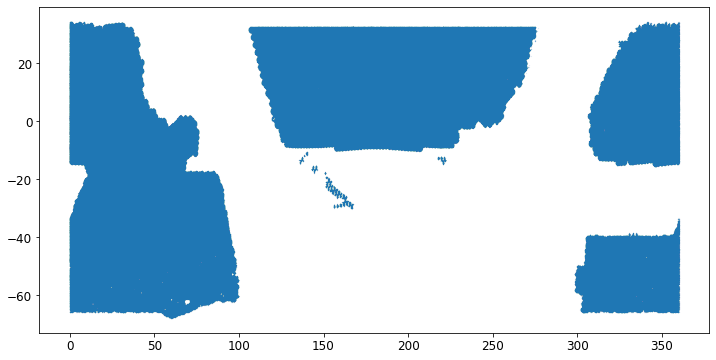

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(cat['RA'], cat['DEC'], '.', ms=0.1)
plt.show()

In [6]:
pz_columns = ['TARGETID', 'Z_PHOT_MEAN', 'Z_PHOT_MEDIAN', 'Z_PHOT_STD', 'Z_PHOT_L68', 'Z_PHOT_U68', 'Z_PHOT_L95', 'Z_PHOT_U95', 'Z_SPEC', 'SURVEY', 'TRAINING', 'KFOLD', 'pz_bin']
newpz = Table(fitsio.read('/Users/rongpu/Documents/Data/lrg_xcorr/catalogs/main_lrg_minobs_1_maskbits_189111213_20210723.fits', columns=pz_columns))

In [7]:
mask = np.in1d(cat['TARGETID'], newpz['TARGETID'])
print(np.sum(~mask))

mask = np.in1d(newpz['TARGETID'], cat['TARGETID'])
newpz = newpz[mask]
print(len(newpz)==len(cat))

cat = join(cat, newpz, keys='TARGETID')

0
True


In [8]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']/cat['MW_TRANSMISSION_G'])
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']/cat['MW_TRANSMISSION_R'])
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']/cat['MW_TRANSMISSION_Z'])
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']/cat['MW_TRANSMISSION_W1'])
    cat['w2mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W2']/cat['MW_TRANSMISSION_W2'])
    cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']/cat['MW_TRANSMISSION_Z'])

21.599998


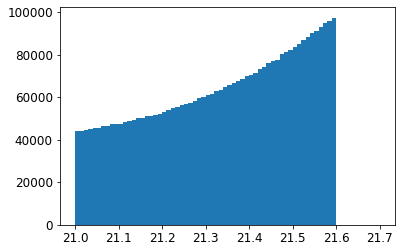

In [9]:
print(np.max(cat['zfibermag']))
plt.hist(cat['zfibermag'], 70, range=(21, 21.7));

In [19]:
mask0 = cat['pz_bin']==2
mask = mask0 & (cat['zfibermag']>21.59)
print(np.sum(mask)/np.sum(mask0))

t = Table()
t['type'], t['count'] = np.unique(cat['TYPE'][mask], return_counts=True)
t['frac (%)'] = t['count']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
t.sort('count')
t

0.0020108653845657435


type,count,frac (%)
str4,int64,float64
PSF,65,1.7
SER,257,6.6
REX,342,8.8
DEV,1275,32.7
EXP,1956,50.2


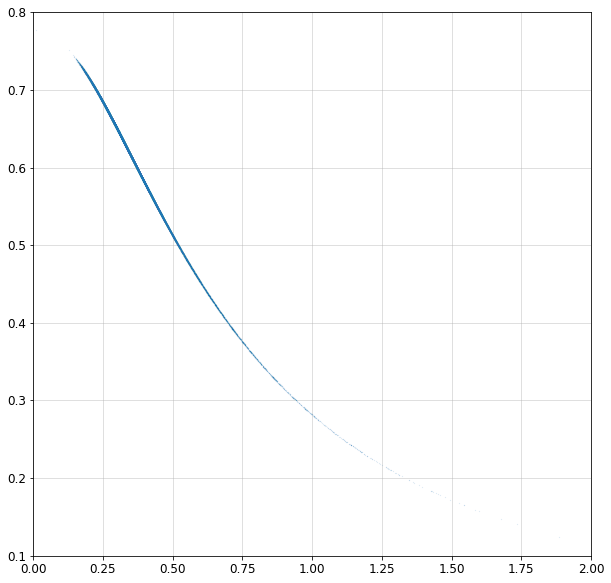

In [52]:
mask = cat['TYPE']=='REX'

plt.figure(figsize=(10, 10))
plt.plot(cat['SHAPE_R'][mask], (cat['FIBERFLUX_Z']/cat['FLUX_Z'])[mask], '.', ms=0.1)
plt.axis([0, 2, 0.1, 0.8])
plt.grid(alpha=0.5)
plt.show()

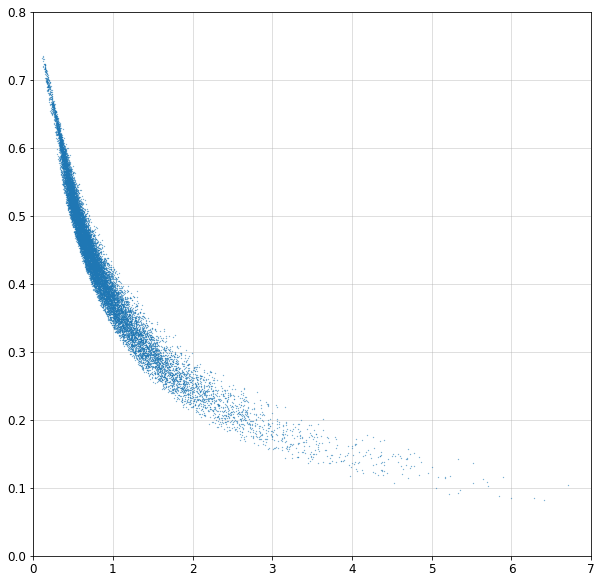

In [60]:
mask = cat['TYPE']=='DEV'

plt.figure(figsize=(10, 10))
plt.plot(cat['SHAPE_R'][mask], (cat['FIBERFLUX_Z']/cat['FLUX_Z'])[mask], '.', ms=0.5)
plt.axis([0, 7, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

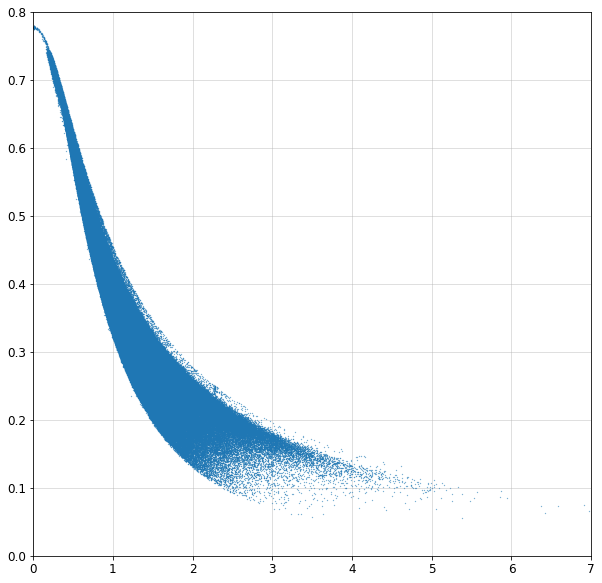

In [26]:
mask = cat['TYPE']=='EXP'

plt.figure(figsize=(10, 10))
plt.plot(cat['SHAPE_R'][mask], (cat['FIBERFLUX_Z']/cat['FLUX_Z'])[mask], '.', ms=0.5)
plt.axis([0, 7, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

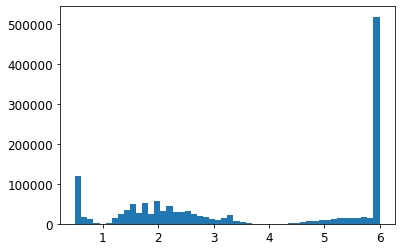

In [20]:
mask = cat['TYPE']=='SER'
plt.hist(cat['SERSIC'][mask], 50);

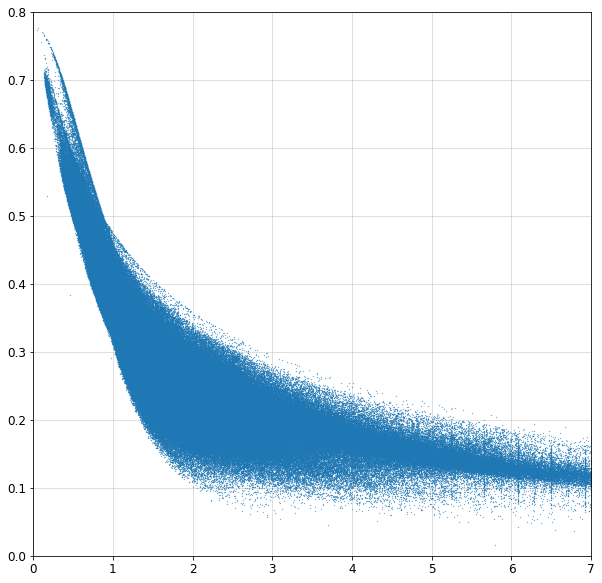

In [24]:
mask = cat['TYPE']=='SER'

plt.figure(figsize=(10, 10))
plt.plot(cat['SHAPE_R'][mask], (cat['FIBERFLUX_Z']/cat['FLUX_Z'])[mask], '.', ms=0.5)
plt.axis([0, 7, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

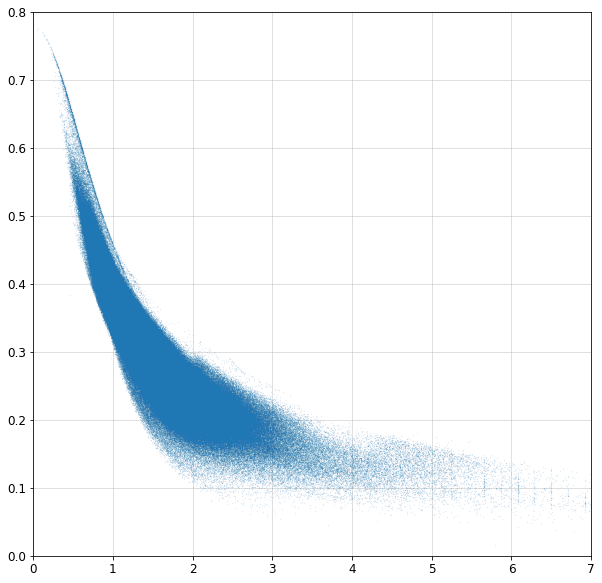

In [25]:
mask = cat['TYPE']=='SER'
mask &= cat['SERSIC']<4

plt.figure(figsize=(10, 10))
plt.plot(cat['SHAPE_R'][mask], (cat['FIBERFLUX_Z']/cat['FLUX_Z'])[mask], '.', ms=0.1)
plt.axis([0, 7, 0., 0.8])

plt.grid(alpha=0.5)
plt.show()

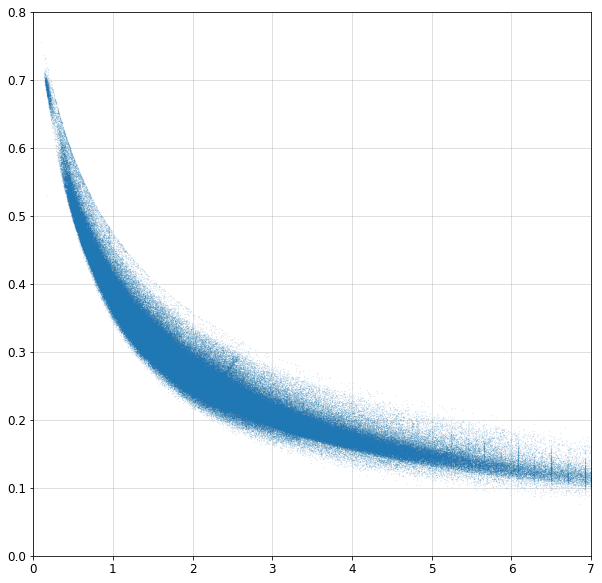

In [27]:
mask = cat['TYPE']=='SER'
mask &= cat['SERSIC']>4

plt.figure(figsize=(10, 10))
plt.plot(cat['SHAPE_R'][mask], (cat['FIBERFLUX_Z']/cat['FLUX_Z'])[mask], '.', ms=0.1)
plt.axis([0, 7, 0., 0.8])

plt.grid(alpha=0.5)
plt.show()

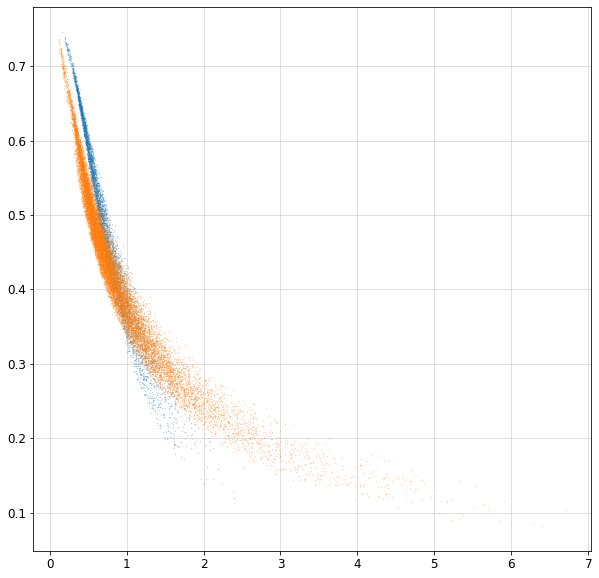

In [31]:
plt.figure(figsize=(10, 10))

mask = cat['TYPE']=='EXP'
plt.plot(cat['SHAPE_R'][mask], (cat['FIBERFLUX_Z']/cat['FLUX_Z'])[mask], '.', ms=0.5, alpha=0.5)

mask = cat['TYPE']=='DEV'
plt.plot(cat['SHAPE_R'][mask], (cat['FIBERFLUX_Z']/cat['FLUX_Z'])[mask], '.', ms=0.5, alpha=0.5)

plt.grid(alpha=0.5)
plt.show()

In [29]:
# axis ratio
e = np.array(np.sqrt(cat['SHAPE_E1']**2+cat['SHAPE_E2']**2))
q = (1+e)/(1-e)

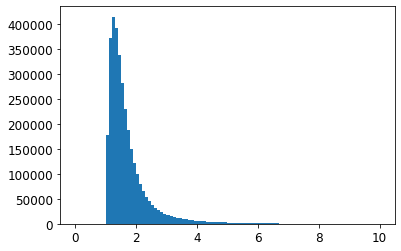

In [36]:
mask = cat['TYPE']=='DEV'

plt.hist(q[mask], 100, range=(0, 10));

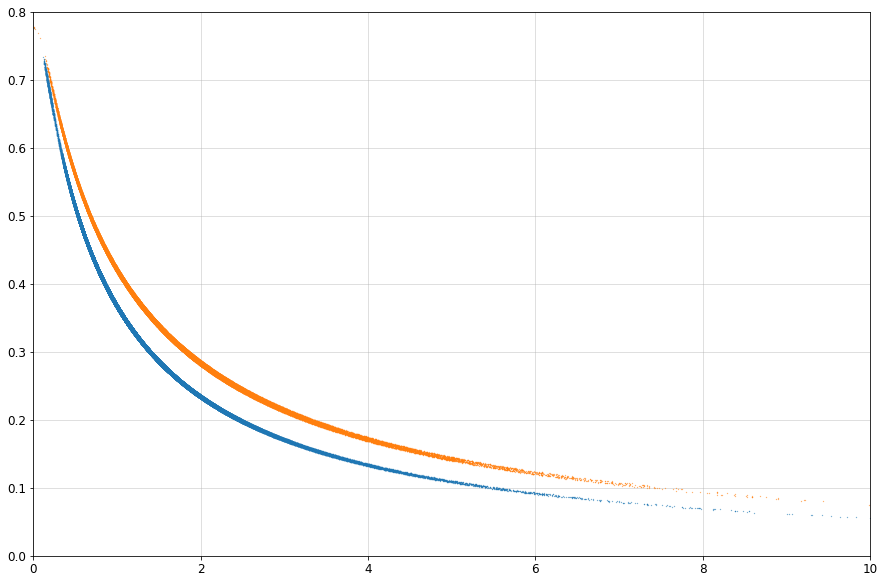

In [37]:
mask = cat['TYPE']=='DEV'
mask &= (q>1.4) & (q<1.5)

plt.figure(figsize=(15, 10))
plt.plot(cat['SHAPE_R'][mask], (cat['FIBERFLUX_Z']/cat['FLUX_Z'])[mask], '.', ms=0.5)

mask = cat['TYPE']=='DEV'
mask &= (q>3) & (q<3.5)
plt.plot(cat['SHAPE_R'][mask], (cat['FIBERFLUX_Z']/cat['FLUX_Z'])[mask], '.', ms=0.5)

plt.axis([0, 10, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

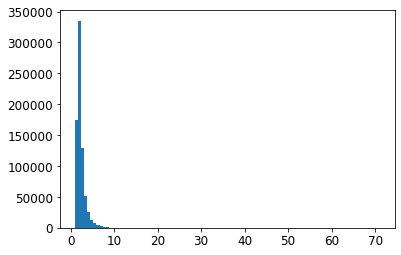

In [32]:
mask = cat['TYPE']=='EXP'

plt.hist(q[mask], 100);

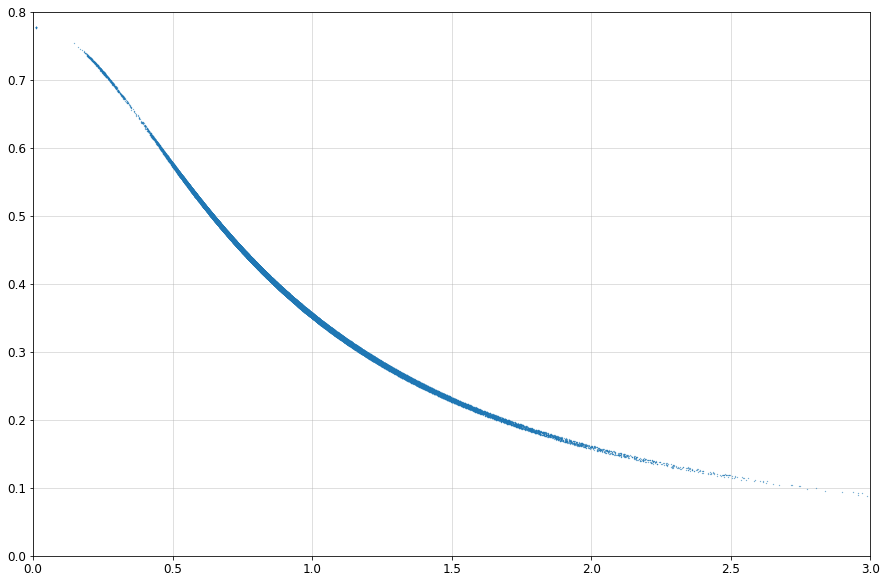

In [33]:
mask = cat['TYPE']=='EXP'
mask &= (q>1.6) & (q<1.7)

plt.figure(figsize=(15, 10))
plt.plot(cat['SHAPE_R'][mask], (cat['FIBERFLUX_Z']/cat['FLUX_Z'])[mask], '.', ms=0.5)
plt.axis([0, 3, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

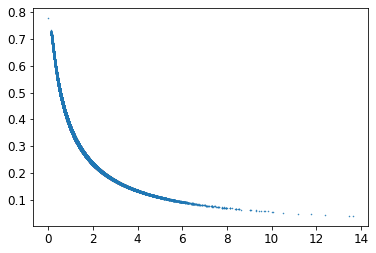

In [45]:
plt.plot(x, y, '.', ms=1)

In [85]:
import statsmodels.api as sm

def rlm_fit1d(x, y, t=1.5, order=1):
    '''
    1D robust polynomial fit.
    
    Given x array and y array, calculate the 1D robust 
    polynomial fit of arbitrary order. Huber weight
    function is used. 
    
    See also poly_val1d.py
    
    INPUT:
    1D arrays of x and y values; tunning parameter t; 
    order of the polynomial fit.
    
    OUTPUT:
    Array of parameters of the polynomial [a0, a1, a2 ...] 
    so that y = a0 + a1*x + a2*x**2 + ...
    '''
    
    ncols = order+1
    a = np.zeros((x.size,ncols))
    for i in range(order+1):
        a[:,i] = x**i
    res = sm.OLS(y, a).fit()
    m = res.params
    return(m)

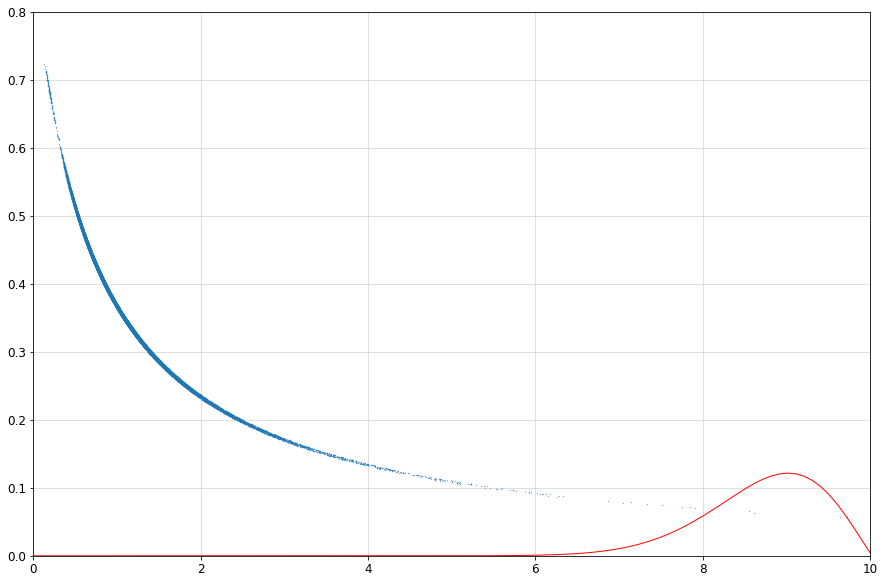

In [96]:
mask = cat['TYPE']=='DEV'
mask &= (q>1.4) & (q<1.5)
x, y = cat['SHAPE_R'][mask].copy(), (cat['FIBERFLUX_Z']/cat['FLUX_Z'])[mask].copy()

poly_order = 30
coeffs_new = rlm_fit1d(x, y, t=0.1, order=poly_order)
coeffs_new = coeffs_new[::-1]

polyfit = np.poly1d(coeffs_new)

x_plot = np.linspace(0, 100, 1000)

plt.figure(figsize=(15, 10))
plt.plot(x[::10], y[::10], '.', ms=0.5)
plt.plot(x_plot, polyfit(x_plot), lw=1, color='r')

plt.axis([0, 10, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

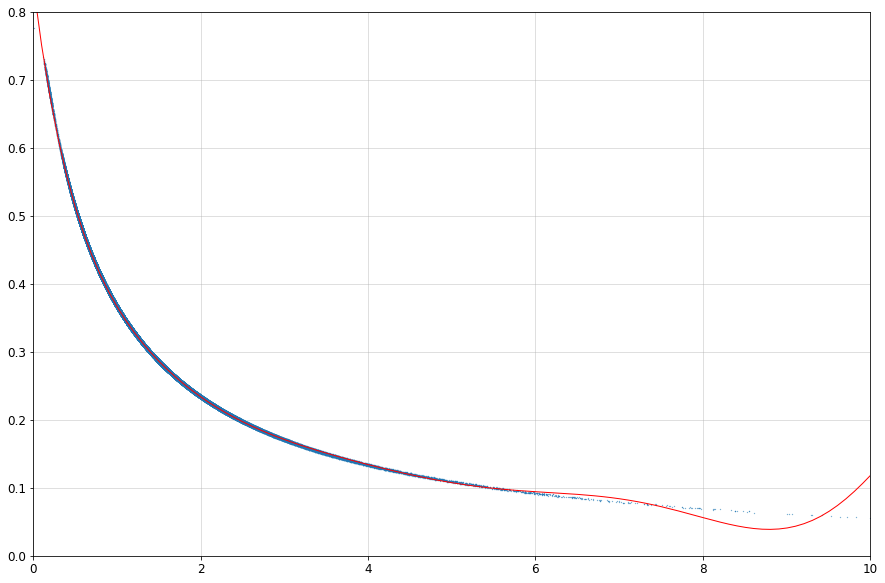

In [73]:
plt.figure(figsize=(15, 10))
plt.plot(x, y, '.', ms=0.5)
plt.plot(x_plot, polyfit(x_plot), lw=1, color='r')
plt.axis([0, 10, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

In [147]:
from scipy.interpolate import interp1d

def binned_stats(x, y, bins):
    from scipy import stats
    bin_center, bin_median = np.zeros((2, len(bins)-1))
    for index in range(len(bins)-1):
        mask = (x>=bins[index]) & (x<=bins[index+1])
        if np.sum(mask)>0:
            bin_center[index] = np.median(x[mask])
            bin_median[index] = np.median(y[mask])
    mask = 
    return bin_center, bin_median, bin_spread

In [173]:
bin_center, bin_median, bin_spread = binned_stats(x, y, bins=np.linspace(x.min(), 10, 50))

mask = bin_median!=0
bin_center = bin_center[mask]
bin_median = bin_median[mask]

interp = interp1d(bin_center, bin_median, bounds_error=False, fill_value='extrapolate', kind='linear')

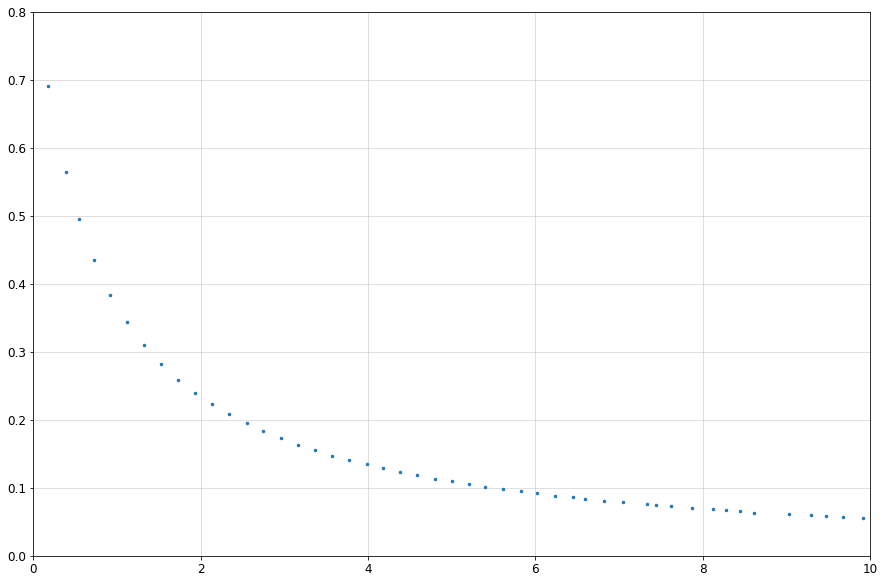

In [174]:
plt.figure(figsize=(15, 10))
plt.plot(bin_center, bin_median, '.', ms=5)
# plt.plot(x_plot, interp(x_plot), lw=1, color='r')
plt.axis([0, 10, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

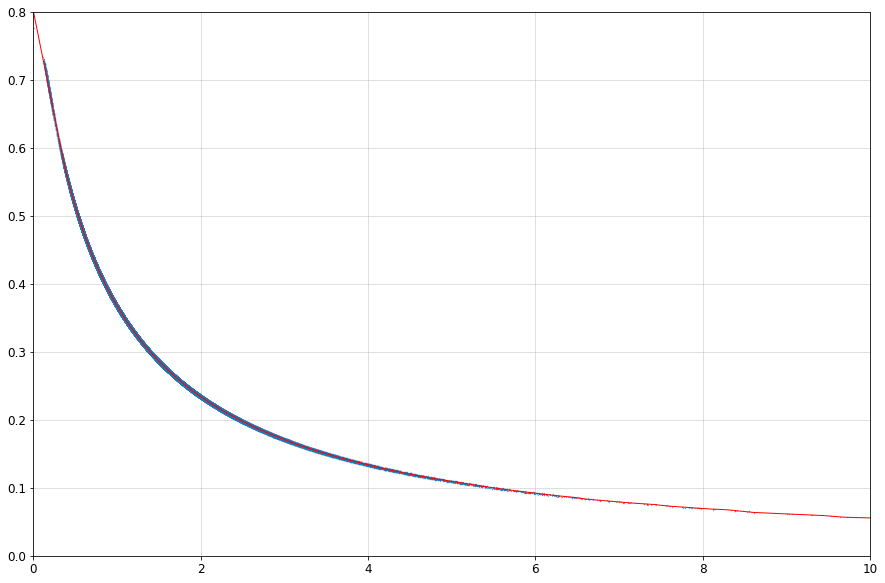

In [175]:
plt.figure(figsize=(15, 10))
plt.plot(x, y, '.', ms=0.5)
plt.plot(x_plot, interp(x_plot), lw=1, color='r')
plt.axis([0, 10, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

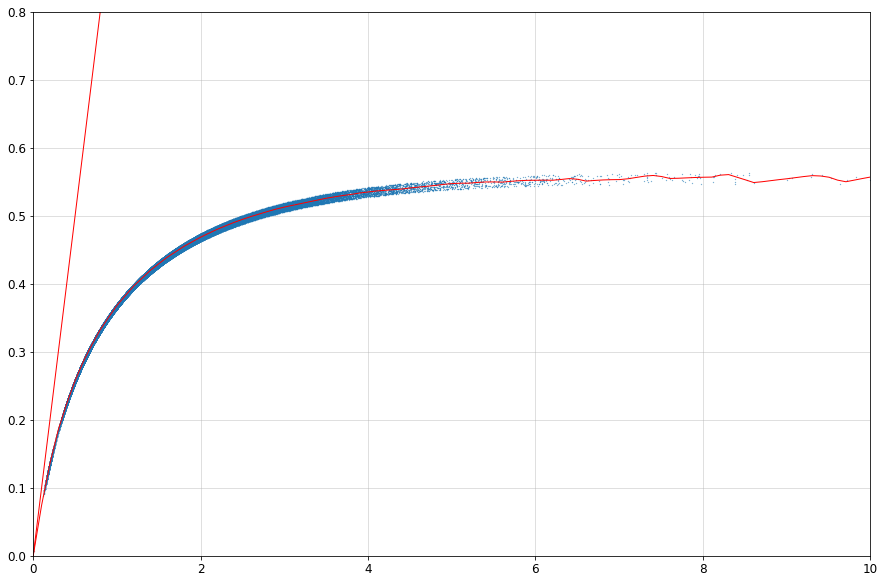

In [182]:
plt.figure(figsize=(15, 10))
plt.plot(x, x * y, '.', ms=0.5)
plt.plot(x_plot, x_plot * interp(x_plot), lw=1, color='r')
plt.plot(x_plot, x_plot, lw=1, color='r')
plt.axis([0, 10, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

In [115]:
bin_center, bin_median, bin_spread

(array([0.18118194, 0.39002523, 0.54828537, 0.7259028 , 0.92557597,
        1.12712836, 1.33186567, 1.53641248, 1.74101973, 1.94498467,
        2.15054345, 2.35661197, 2.56134701, 2.76400089, 2.97210574,
        3.17730141, 3.38375139, 3.58686709, 3.79633927, 4.00400639,
        4.20781136, 4.41223335, 4.60684824, 4.81660748, 5.0300355 ,
        5.23799133, 5.42166281, 5.62614679, 5.86882448, 6.05316448,
        6.24938869, 6.4654808 , 6.6424799 , 6.87190962, 7.05597305,
        7.33599997, 7.47730732, 7.70617104, 7.93418217]),
 array([0.69160742, 0.56394911, 0.49444821, 0.43492669, 0.38335577,
        0.34261724, 0.30924171, 0.28169423, 0.25862128, 0.23897293,
        0.22203383, 0.20711383, 0.19420774, 0.18272416, 0.17231555,
        0.16293167, 0.15460706, 0.14707498, 0.14015368, 0.13373311,
        0.12790571, 0.12254412, 0.11757344, 0.1130418 , 0.10885988,
        0.10498962, 0.1009449 , 0.09774888, 0.09392738, 0.09107423,
        0.08835334, 0.08610829, 0.08310807, 0.08080548, 0.

In [150]:
bin_center

array([0.18078624, 0.38815421, 0.54609942, 0.72260624, 0.92093623,
       1.1221503 , 1.32556581, 1.52901292, 1.73315835, 1.9362514 ,
       2.13986945, 2.34405136, 2.54909039, 2.74980736, 2.95704126,
       3.15980506, 3.36605549, 3.57545757, 3.77467847, 3.98290539,
       4.17851543, 4.37807369, 4.58467484, 4.79713631, 5.0080986 ,
       5.20709991, 5.39471483, 5.60872889, 5.82850599, 6.02109814,
       6.22834682, 6.45031071, 6.59814024, 6.82124329, 7.05085516,
       7.33599997, 7.44172955, 7.61911964, 7.87021208, 8.12336349,
       8.27410603, 8.44774818, 8.61743641, 0.        , 9.03544998,
       9.29829979, 9.4754591 , 9.68068695, 9.91247368])